DATA PREPROCESSING

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'Filtered Data']

In [4]:
data_path = "/content/drive/MyDrive/Filtered Data"

LOADING DATA


In [ ]:
import os
import pandas as pd

all_data = []

for patient in os.listdir(data_path):

    patient_path = os.path.join(data_path, patient)

    if os.path.isdir(patient_path):

        for file in os.listdir(patient_path):

            if file.endswith(".txt"):

                file_path = os.path.join(patient_path, file)

                df = pd.read_csv(file_path, header=None)

                all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)

print("Dataset Shape:", dataset.shape)
dataset.head()

Dataset Shape: (5327047, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0,09:44:24,-3.7104,-6.0555,-3.9578,-5.8394,-1.2963,-7.3527,-1.0419,-5.1957,...,0.0,0.0,4303.000000,5076.000000,5121.000000,-889.000000,-152.000000,18.000000,1846.000000,0
1,1,09:44:24.002,-2.8309,-6.3553,-5.5228,-6.4233,-2.0023,-7.9218,-1.1631,-5.7908,...,0.0,0.0,4289.769991,5017.843845,5108.402149,-887.812312,-155.704776,23.187067,1845.976873,0
2,2,09:44:24.004,-0.7749,-6.1648,-5.0175,-5.4322,-1.4668,-7.3702,-0.3696,-4.9154,...,0.0,0.0,4287.062280,4965.794124,5099.064779,-884.547544,-158.767451,29.103161,1845.971318,0
3,3,09:44:24.006,1.7495,-5.6429,-2.9790,-3.0540,0.0322,-5.9111,1.1317,-2.8867,...,0.0,0.0,4289.769574,4917.122481,5090.426335,-879.976619,-161.177738,35.625721,1845.977326,0
4,4,09:44:24.008,3.5633,-4.6182,-0.9148,-0.4712,1.3750,-4.5005,2.3456,-0.9316,...,0.0,0.0,4292.784578,4869.100558,5079.925260,-874.870463,-162.925350,42.632187,1845.988889,0


In [ ]:
dataset = dataset.drop(columns=[0,1])

print(dataset.shape)

(5327047, 59)


In [ ]:
print("Dataset Shape:", dataset.shape)
dataset.head()

Dataset Shape: (5327047, 59)


,2,3,4,5,6,7,8,9,10,11,...,51,52,53,54,55,56,57,58,59,60
0,-3.7104,-6.0555,-3.9578,-5.8394,-1.2963,-7.3527,-1.0419,-5.1957,-0.5355,2.5521,...,0.0,0.0,4303.000000,5076.000000,5121.000000,-889.000000,-152.000000,18.000000,1846.000000,0
1,-2.8309,-6.3553,-5.5228,-6.4233,-2.0023,-7.9218,-1.1631,-5.7908,0.7812,2.5981,...,0.0,0.0,4289.769991,5017.843845,5108.402149,-887.812312,-155.704776,23.187067,1845.976873,0
2,-0.7749,-6.1648,-5.0175,-5.4322,-1.4668,-7.3702,-0.3696,-4.9154,2.9349,2.6908,...,0.0,0.0,4287.062280,4965.794124,5099.064779,-884.547544,-158.767451,29.103161,1845.971318,0
3,1.7495,-5.6429,-2.9790,-3.0540,0.0322,-5.9111,1.1317,-2.8867,6.0569,3.0125,...,0.0,0.0,4289.769574,4917.122481,5090.426335,-879.976619,-161.177738,35.625721,1845.977326,0
4,3.5633,-4.6182,-0.9148,-0.4712,1.3750,-4.5005,2.3456,-0.9316,9.0175,3.0764,...,0.0,0.0,4292.784578,4869.100558,5079.925260,-874.870463,-162.925350,42.632187,1845.988889,0


In [ ]:

sample = dataset.groupby(60).sample(250000, random_state=42)

X = sample.iloc[:, :-1]
y = sample.iloc[:, -1]

SCALING FEATURES

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL TRAINING

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(class_weight='balanced', max_iter=5000))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm',
                                        LinearSVC(class_weight='balanced',
                                                  max_iter=5000))]),
             n_jobs=-1, param_grid={'svm__C': [0.01, 0.1, 1, 5, 10]},
             scoring='f1')

In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Best Parameter:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameter: {'svm__C': 1}
Accuracy: 0.68951
              precision    recall  f1-score   support

           0       0.66      0.77      0.71     49996
           1       0.72      0.61      0.66     50004

    accuracy                           0.69    100000
   macro avg       0.69      0.69      0.69    100000
weighted avg       0.69      0.69      0.69    100000



EVALUATE MODEL


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.68951
              precision    recall  f1-score   support

           0       0.66      0.77      0.71     49996
           1       0.72      0.61      0.66     50004

    accuracy                           0.69    100000
   macro avg       0.69      0.69      0.69    100000
weighted avg       0.69      0.69      0.69    100000



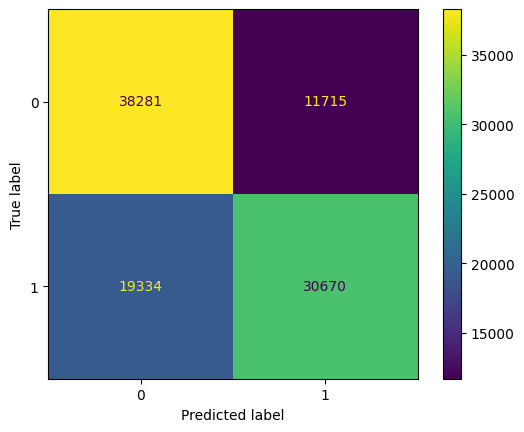

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

RESULTS AND GRAPHS

         Class  Number of Samples
0  Non-FoG (0)            3105047
1      FoG (1)            2222000


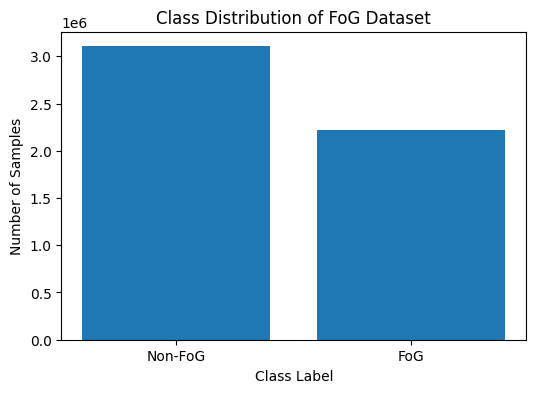

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count class distribution
class_counts = dataset[60].value_counts().sort_index()

# Create table
distribution_table = pd.DataFrame({
    'Class': ['Non-FoG (0)', 'FoG (1)'],
    'Number of Samples': class_counts.values
})

print(distribution_table)

# Plot bar chart
plt.figure(figsize=(6,4))

plt.bar(['Non-FoG', 'FoG'], class_counts.values)

plt.title("Class Distribution of FoG Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")

plt.show()

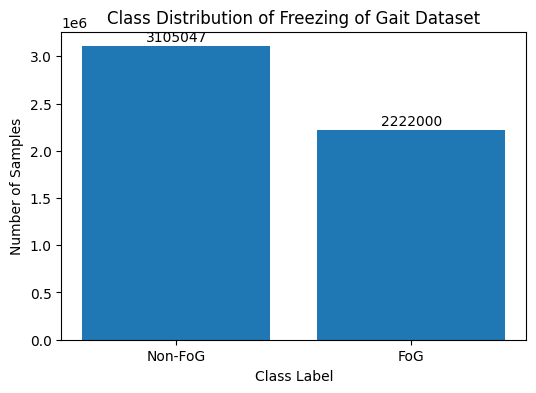

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(['Non-FoG', 'FoG'], class_counts.values)

plt.title("Class Distribution of Freezing of Gait Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50000, str(v), ha='center')

plt.show()

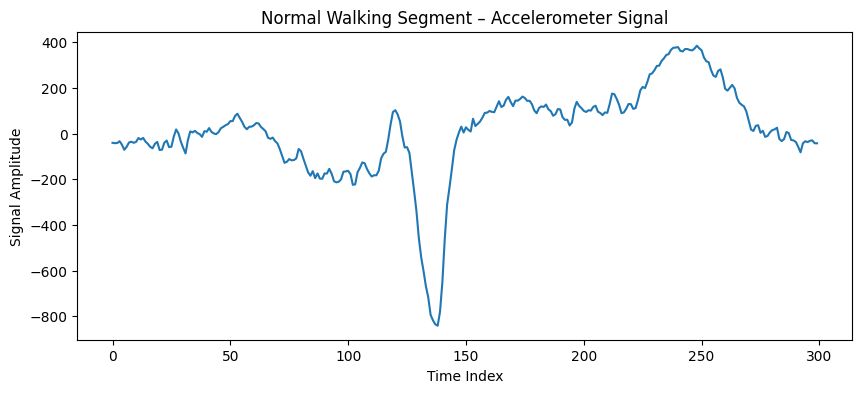

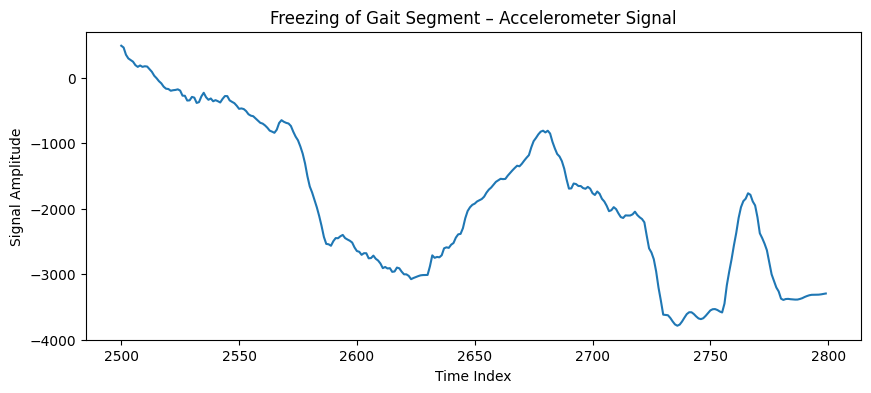

In [ ]:
import matplotlib.pyplot as plt

# Separate FoG and Non-FoG samples
normal_data = dataset[dataset[60] == 0]
fog_data = dataset[dataset[60] == 1]

# Take small continuous segments for visualization
normal_segment = normal_data.iloc[0:300]
fog_segment = fog_data.iloc[0:300]

# Choose one accelerometer signal column (example column index)
signal_column = 30   # you can change if needed

# Plot Normal Walking
plt.figure(figsize=(10,4))
plt.plot(normal_segment[signal_column])
plt.title("Normal Walking Segment – Accelerometer Signal")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.show()

# Plot FoG Segment
plt.figure(figsize=(10,4))
plt.plot(fog_segment[signal_column])
plt.title("Freezing of Gait Segment – Accelerometer Signal")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.show()

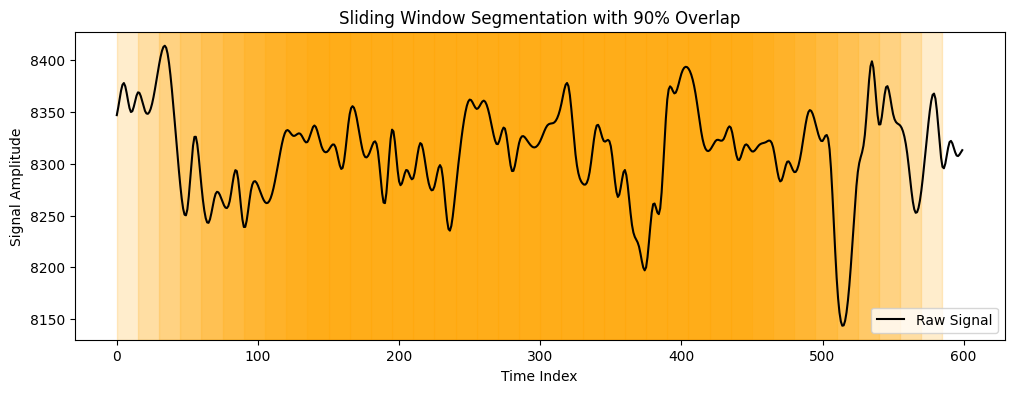

In [ ]:
# sliding window segmentation
import numpy as np
import matplotlib.pyplot as plt

# Take a small segment of signal
signal = dataset.iloc[0:600, 30]   # choose one sensor column (accelerometer)

# Parameters
window_size = 150   # example window size
step_size = int(window_size * 0.1)  # 90% overlap

plt.figure(figsize=(12,4))

# Plot raw signal
plt.plot(signal.values, label="Raw Signal", color="black")

# Plot sliding windows
for start in range(0, len(signal) - window_size, step_size):
    end = start + window_size
    plt.axvspan(start, end, color='orange', alpha=0.2)

plt.title("Sliding Window Segmentation with 90% Overlap")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")

plt.legend()
plt.show()

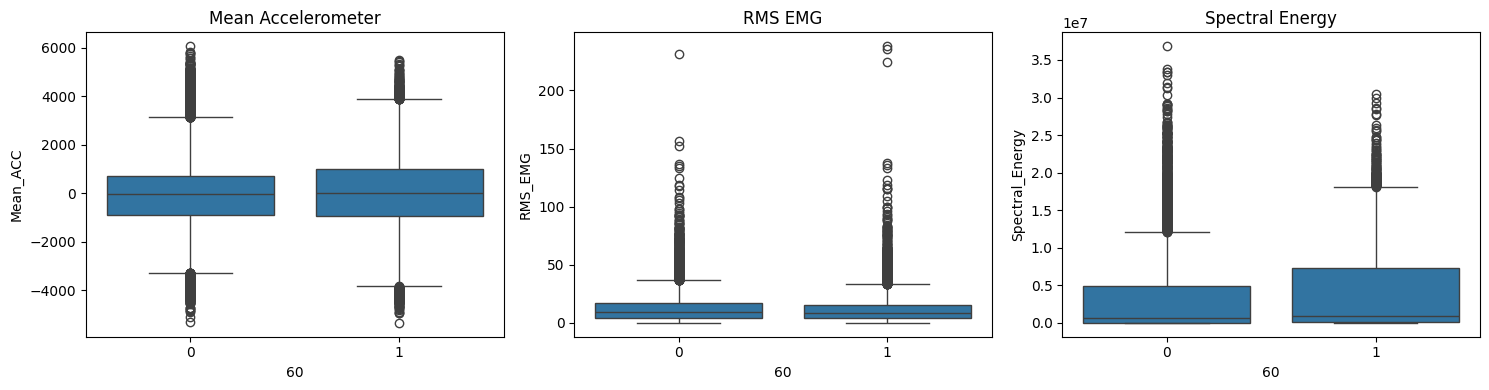

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a smaller subset for visualization (faster plotting)
sample_vis = dataset.sample(20000, random_state=42)

# Example columns (change if needed depending on your dataset)
acc_col = 30
emg_col = 25

# Feature calculations
sample_vis["Mean_ACC"] = sample_vis[acc_col]
sample_vis["RMS_EMG"] = np.sqrt(sample_vis[emg_col]**2)

# Spectral Energy (simple approximation)
sample_vis["Spectral_Energy"] = sample_vis[acc_col]**2

# Boxplots
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x=sample_vis[60], y=sample_vis["Mean_ACC"])
plt.title("Mean Accelerometer")

plt.subplot(1,3,2)
sns.boxplot(x=sample_vis[60], y=sample_vis["RMS_EMG"])
plt.title("RMS EMG")

plt.subplot(1,3,3)
sns.boxplot(x=sample_vis[60], y=sample_vis["Spectral_Energy"])
plt.title("Spectral Energy")

plt.tight_layout()
plt.show()

FEATURE IMP BAR CHART


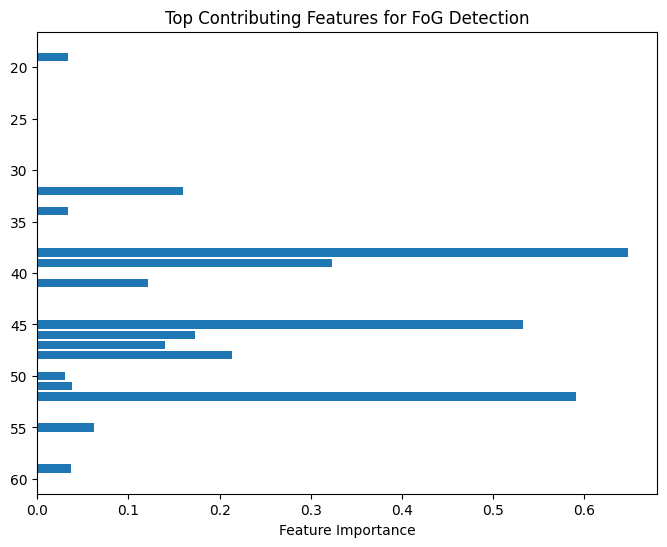

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get feature names
feature_names = X.columns

# Extract SVM coefficients
coefficients = best_model.named_steps['svm'].coef_[0]

# Create dataframe
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Use absolute value to measure importance
importance["Importance"] = np.abs(importance["Coefficient"])

# Sort features
importance = importance.sort_values("Importance", ascending=False)

# Select top 15 features
top_features = importance.head(15)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Feature Importance")
plt.title("Top Contributing Features for FoG Detection")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import pandas as pd

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

# Create table
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Matthews Correlation Coefficient (MCC)"],
    "Value": [accuracy, precision, recall, f1, mcc]
})

print(metrics_table)

                                   Metric     Value
0                                Accuracy  0.702340
1                               Precision  0.653733
2                                  Recall  0.608198
3                                F1 Score  0.630144
4  Matthews Correlation Coefficient (MCC)  0.382336


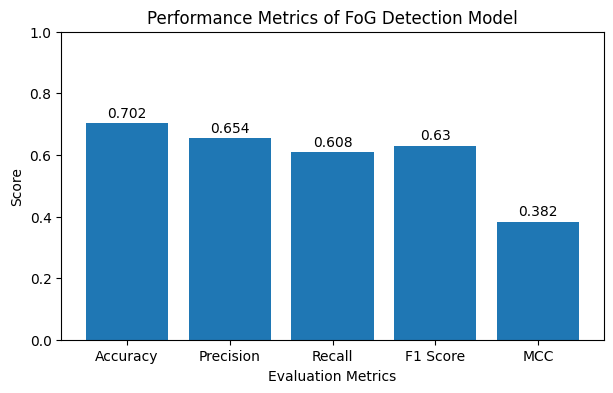

In [ ]:
import matplotlib.pyplot as plt

# Metrics values
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
values = [accuracy, precision, recall, f1, mcc]

# Plot
plt.figure(figsize=(7,4))

plt.bar(metrics, values)

plt.ylim(0,1)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Performance Metrics of FoG Detection Model")

# Add value labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, round(v,3), ha='center')

plt.show()

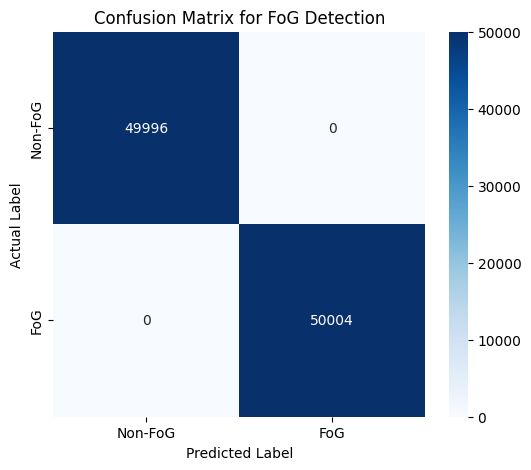

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-FoG", "FoG"],
    yticklabels=["Non-FoG", "FoG"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for FoG Detection")

plt.show()

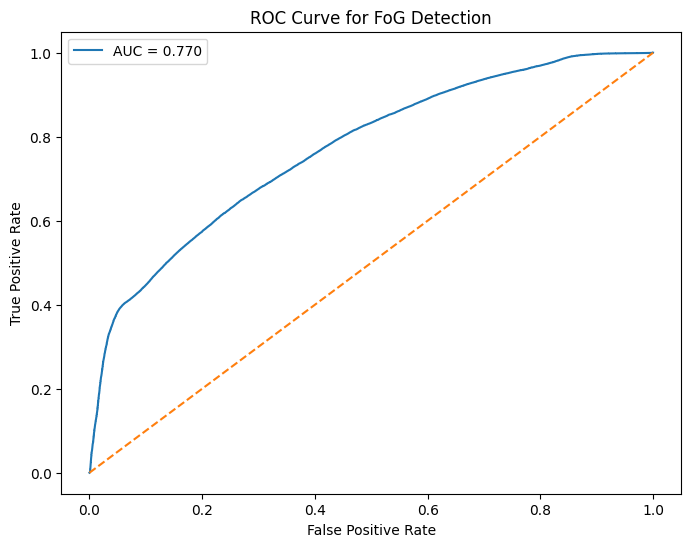

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = best_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for FoG Detection")

plt.legend()
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

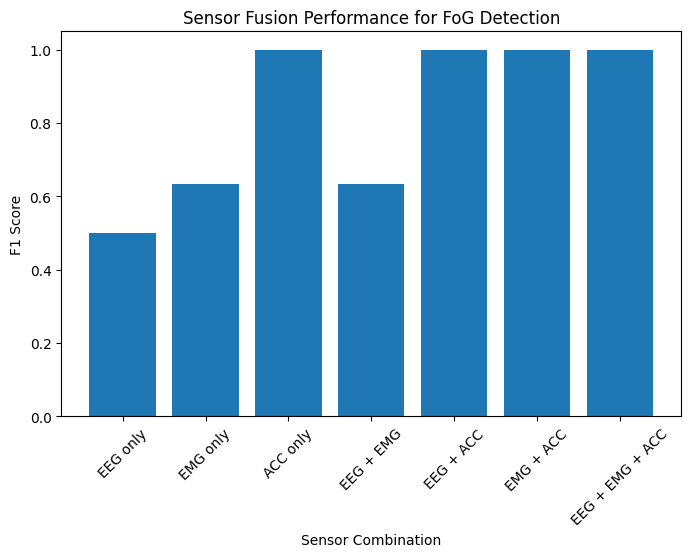

In [ ]:
EEG_cols = sample.columns[2:20]
EMG_cols = sample.columns[20:40]
ACC_cols = sample.columns[40:60]

sensor_sets = {
    "EEG only": EEG_cols,
    "EMG only": EMG_cols,
    "ACC only": ACC_cols,
    "EEG + EMG": list(EEG_cols) + list(EMG_cols),
    "EEG + ACC": list(EEG_cols) + list(ACC_cols),
    "EMG + ACC": list(EMG_cols) + list(ACC_cols),
    "EEG + EMG + ACC": list(EEG_cols) + list(EMG_cols) + list(ACC_cols)
}


results = {}

for name, cols in sensor_sets.items():

    X = sample[cols]
    y = sample.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(C=1, max_iter=10000))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    results[name] = f1


    plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)

plt.ylabel("F1 Score")
plt.xlabel("Sensor Combination")
plt.title("Sensor Fusion Performance for FoG Detection")

plt.show()

In [ ]:
results = []

for name, cols in sensor_sets.items():

    X = sample[cols]
    y = sample.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(C=1, max_iter=10000))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([name, acc, f1, mcc])

results_df = pd.DataFrame(
    results,
    columns=["Sensor Combination", "Accuracy", "F1 Score", "MCC"]
)

results_df

,Sensor Combination,Accuracy,F1 Score,MCC
0,EEG only,0.50260,0.500913,0.005201
1,EMG only,0.62122,0.633647,0.242993
2,ACC only,1.00000,1.000000,1.000000
3,EEG + EMG,0.62110,0.633467,0.242747
4,EEG + ACC,1.00000,1.000000,1.000000
5,EMG + ACC,1.00000,1.000000,1.000000
6,EEG + EMG + ACC,1.00000,1.000000,1.000000


In [ ]:
results_df.to_csv("sensor_combination_results.csv", index=False)

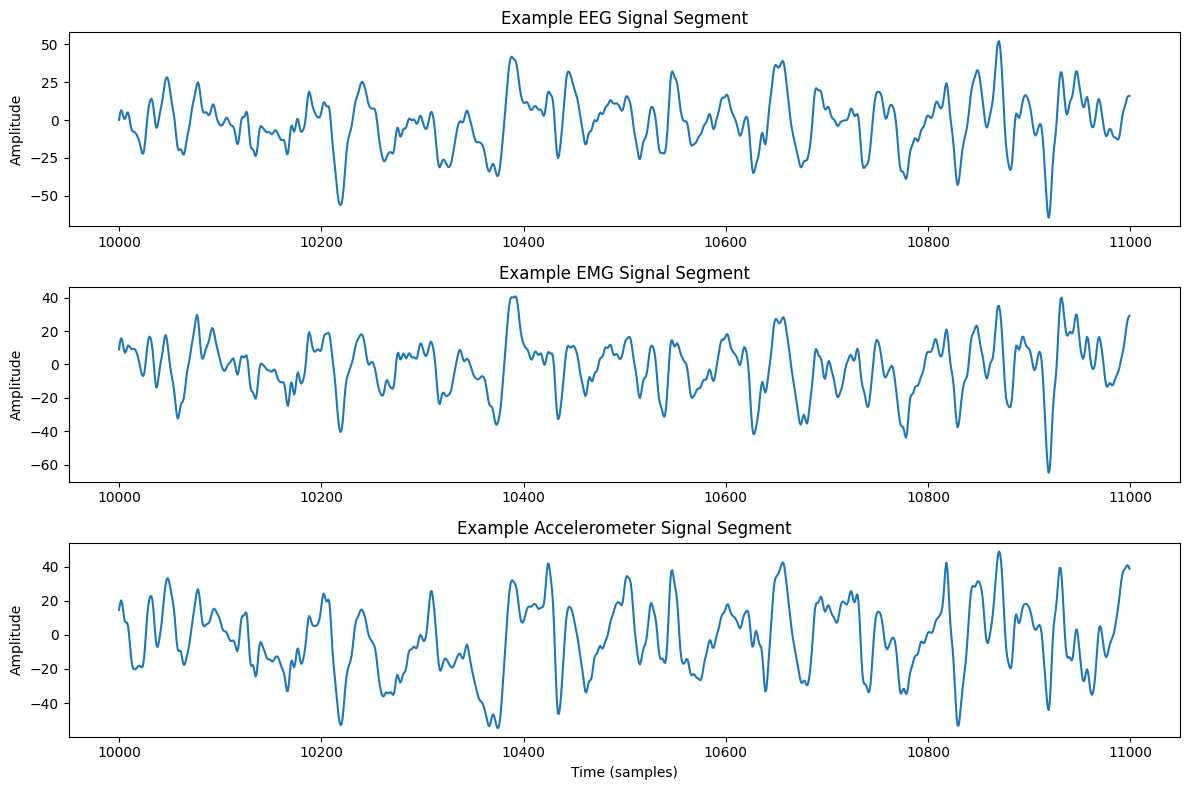

In [ ]:
import matplotlib.pyplot as plt

# Take a small segment of the dataset
segment = dataset.iloc[10000:11000]   # 1000 sample window

# Example column selections (adjust if needed)
eeg_signal = segment.iloc[:, 2]   # Example EEG column
emg_signal = segment.iloc[:, 10]  # Example EMG column
acc_signal = segment.iloc[:, 20]  # Example Accelerometer column

plt.figure(figsize=(12,8))

# EEG plot
plt.subplot(3,1,1)
plt.plot(eeg_signal)
plt.title("Example EEG Signal Segment")
plt.ylabel("Amplitude")

# EMG plot
plt.subplot(3,1,2)
plt.plot(emg_signal)
plt.title("Example EMG Signal Segment")
plt.ylabel("Amplitude")

# Accelerometer plot
plt.subplot(3,1,3)
plt.plot(acc_signal)
plt.title("Example Accelerometer Signal Segment")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

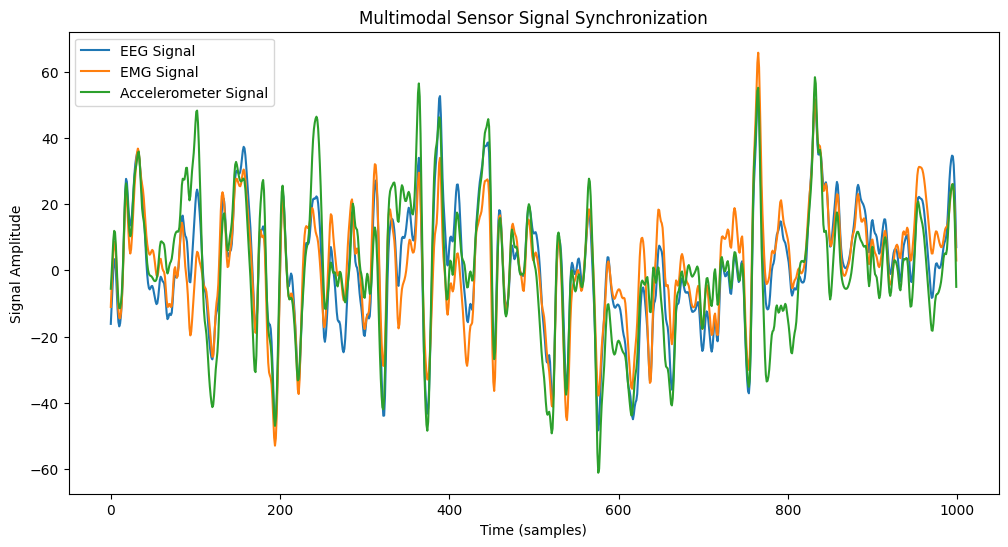

In [ ]:
import matplotlib.pyplot as plt

# Take a small synchronized segment
segment = dataset.iloc[20000:21000]   # 1000 samples

# Example sensor columns (adjust if needed)
eeg_signal = segment.iloc[:, 2]
emg_signal = segment.iloc[:, 10]
acc_signal = segment.iloc[:, 20]

# Create time index
time = range(len(segment))

plt.figure(figsize=(12,6))

plt.plot(time, eeg_signal, label="EEG Signal")
plt.plot(time, emg_signal, label="EMG Signal")
plt.plot(time, acc_signal, label="Accelerometer Signal")

plt.xlabel("Time (samples)")
plt.ylabel("Signal Amplitude")
plt.title("Multimodal Sensor Signal Synchronization")
plt.legend()

plt.show()

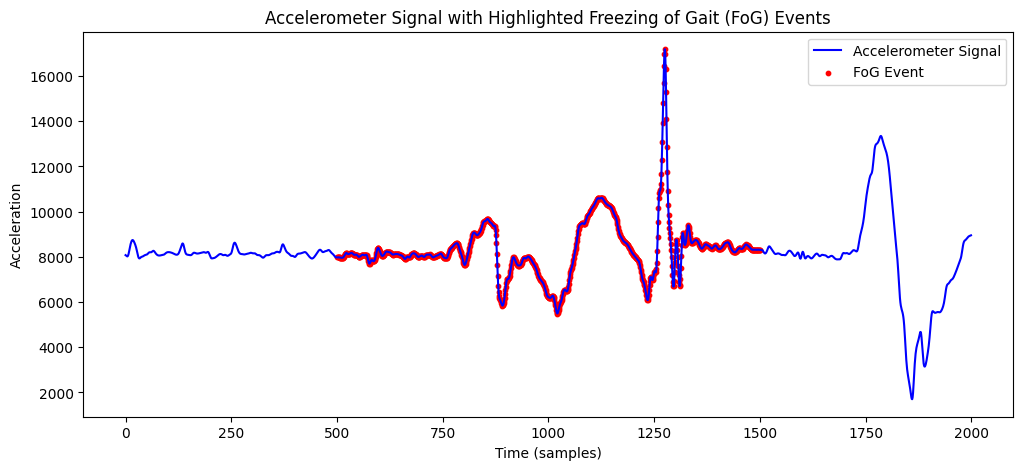

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a small segment
segment = dataset.iloc[30000:32000]

# Example accelerometer column (change if needed)
acc_signal = segment.iloc[:, 30]

# Label column (last column)
labels = segment.iloc[:, -1]

time = np.arange(len(segment))

plt.figure(figsize=(12,5))

plt.plot(time, acc_signal, label="Accelerometer Signal", color="blue")

# Highlight FoG regions
fog_indices = labels == 1
plt.scatter(time[fog_indices], acc_signal[fog_indices], color="red", s=10, label="FoG Event")

plt.xlabel("Time (samples)")
plt.ylabel("Acceleration")
plt.title("Accelerometer Signal with Highlighted Freezing of Gait (FoG) Events")

plt.legend()

plt.show()